In [ ]:
!pip install obspy

In [1]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client

# Initialize the IRIS client
client = Client("IRIS")
# Define the time range for data retrieval
start_time = UTCDateTime("2023-01-01T00:00:00")
end_time = UTCDateTime("2023-01-01T01:00:00")
# Specify the seismic station parameters
network = "IU"  # Network code
station = "ANMO"  # Station code
location = "00"  # Location code
channel = "BHZ"  # Channel code (e.g., BHZ for broadband high-gain vertical)
# Retrieve the data
st = client.get_waveforms(network, station, location, channel, start_time, end_time)
# Display the retrieved data
print(st)
# Remove the instrument response to obtain ground displacement
st.remove_response(output="DISP")
# Apply a bandpass filter to isolate frequencies of interest
st.filter("bandpass", freqmin=0.1, freqmax=10.0)
# Plot the preprocessed data
st.plot()
from obspy.signal.trigger import classic_sta_lta, trigger_onset

# Select the first trace in the stream
tr = st[0]
# Apply the STA/LTA algorithm
sta_lta = classic_sta_lta(tr.data, nsta=500, nlta=10000)
# Define trigger thresholds
trigger_on = 3.5
trigger_off = 1.0
# Identify trigger onsets
onsets = trigger_onset(sta_lta, trigger_on, trigger_off)
# Print detected event onsets
for onset in onsets:
    print(
        f"Event detected from {tr.stats.starttime + onset[0] / tr.stats.sampling_rate} "
        f"to {tr.stats.starttime + onset[1] / tr.stats.sampling_rate}"
    )
import matplotlib.pyplot as plt

# Extract and plot the first detected event
if onsets:
    event_start = tr.stats.starttime + onsets[0][0] / tr.stats.sampling_rate
    event_end = tr.stats.starttime + onsets[0][1] / tr.stats.sampling_rate
    event_trace = tr.slice(starttime=event_start, endtime=event_end)
    # Plot the event
    plt.figure()
    plt.plot(event_trace.times("matplotlib"), event_trace.data, label="Detected Event")
    plt.xlabel("Time")
    plt.ylabel("Displacement (m)")
    plt.legend()
    plt.show()

1 Trace(s) in Stream:
IU.ANMO.00.BHZ | 2023-01-01T00:00:00.019538Z - 2023-01-01T00:59:59.994538Z | 40.0 Hz, 144000 samples


ValueError: No response information found. Use `inventory` parameter to specify an inventory with response information.

In [17]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client

# Initialize the IRIS client
client = Client("IRIS")

# Define the time range for data retrieval
start_time = UTCDateTime("2025-02-12T00:00:00")
end_time = UTCDateTime("2025-02-13T01:00:00")

# Specify the seismic station parameters
network = "IU"  # Network code
station = "ANMO"  # Station code
location = "00"  # Location code
channel = "BHZ"  # Channel code

# Retrieve the waveform data
st = client.get_waveforms(network, station, location, channel, start_time, end_time)

# Retrieve the station metadata (response information)
inventory = client.get_stations(
    network=network,
    station=station,
    location=location,
    channel=channel,
    starttime=start_time,
    endtime=end_time,
    level="response",
)

# Print the retrieved data
print(st)

# Remove the instrument response to obtain ground displacement
st.remove_response(inventory=inventory, output="DISP")

# Apply a bandpass filter to isolate frequencies of interest
st.filter("bandpass", freqmin=0.1, freqmax=10.0)

# Plot the preprocessed data
st.plot(outfile="waveform.png")

1 Trace(s) in Stream:
IU.ANMO.00.BHZ | 2025-02-12T00:00:00.019538Z - 2025-02-13T00:59:59.994538Z | 40.0 Hz, 3600000 samples


Event detected from 2025-02-12T00:04:22.819538Z to 2025-02-12T00:05:26.444538Z
Event detected from 2025-02-12T00:07:42.069538Z to 2025-02-12T00:08:04.044538Z
Event detected from 2025-02-12T00:09:47.969538Z to 2025-02-12T00:10:03.869538Z
Event detected from 2025-02-12T00:11:07.019538Z to 2025-02-12T00:11:45.019538Z
Event detected from 2025-02-12T00:18:14.594538Z to 2025-02-12T00:18:34.319538Z
Event detected from 2025-02-12T00:21:19.344538Z to 2025-02-12T00:21:38.944538Z
Event detected from 2025-02-12T00:22:39.319538Z to 2025-02-12T00:23:20.244538Z
Event detected from 2025-02-12T00:34:30.044538Z to 2025-02-12T00:34:49.919538Z
Event detected from 2025-02-12T00:45:03.919538Z to 2025-02-12T00:45:23.394538Z
Event detected from 2025-02-12T00:49:04.719538Z to 2025-02-12T00:49:42.144538Z
Event detected from 2025-02-12T01:00:23.519538Z to 2025-02-12T01:00:42.144538Z
Event detected from 2025-02-12T01:15:19.094538Z to 2025-02-12T01:16:36.744538Z
Event detected from 2025-02-12T01:24:45.694538Z to 2

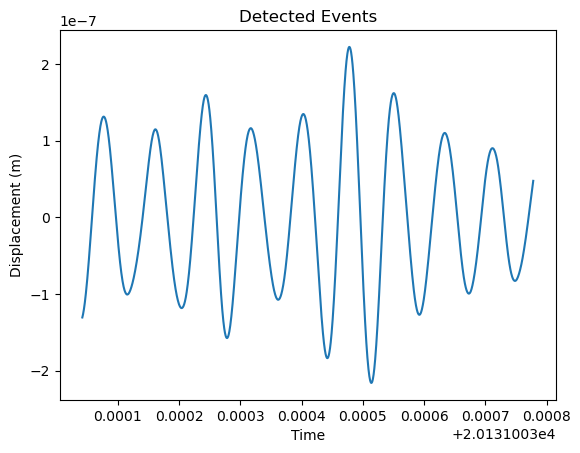

In [23]:
from obspy.signal.trigger import classic_sta_lta, trigger_onset

# Select the first trace in the stream
tr = st[0]
# Apply the STA/LTA algorithm
sta_lta = classic_sta_lta(tr.data, nsta=500, nlta=10000)
# Define trigger thresholds
trigger_on = 3.5
trigger_off = 1.0
# Identify trigger onsets
onsets = trigger_onset(sta_lta, trigger_on, trigger_off)
# Print detected event onsets
for onset in onsets:
    print(
        f"Event detected from {tr.stats.starttime + onset[0] / tr.stats.sampling_rate} "
        f"to {tr.stats.starttime + onset[1] / tr.stats.sampling_rate}"
    )
import matplotlib.pyplot as plt

# Extract and plot the first detected event
if len(onsets) > 0:
    event_start = tr.stats.starttime + onsets[0][0] / tr.stats.sampling_rate
    event_end = tr.stats.starttime + onsets[0][1] / tr.stats.sampling_rate
    event_trace = tr.slice(starttime=event_start, endtime=event_end)
    # Plot the event
    plt.figure()
    plt.plot(event_trace.times("matplotlib"), event_trace.data, label="Detected Event")
    plt.xlabel("Time")
    plt.ylabel("Displacement (m)")
    plt.title("Detected Events")
    plt.savefig("detected_event.png")
    plt.show()